In [1]:
import pandas as pd 
import numpy as np
import glob
import re
import matplotlib.pyplot as plt
import seaborn as sns

# Stock Price Data

In [2]:
# collection of stock price data
import yfinance as yf

ticker = "BBCA.JK" 
stock = yf.download(ticker, start="2019-01-01", end="2025-01-31")

stock.to_csv("BBCA_historical.csv")

stock = pd.read_csv('BBCA_historical.csv')
stock


Initial Cleaning & Formatting 

In [2]:
stock = pd.read_csv('BBCA_historical.csv')
stock

,Price,Close,High,Low,Open,Volume
0,Ticker,BBCA.JK,BBCA.JK,BBCA.JK,BBCA.JK,BBCA.JK
1,Date,NaN,NaN,NaN,NaN,NaN
2,2019-01-01,4469.3583984375,4469.3583984375,4469.3583984375,4469.3583984375,0
3,2019-01-02,4503.73779296875,4508.0352526948645,4469.358115159828,4469.358115159828,35956000
4,2019-01-03,4452.1689453125,4486.548628287886,4396.301960477497,4469.358786800193,72358000
...,...,...,...,...,...,...
1484,2025-01-21,9289.1796875,9386.194618962141,9264.925954634466,9313.433420365536,124547900
1485,2025-01-22,9313.4326171875,9386.193809509277,9289.178886413574,9361.940078735352,90154800
1486,2025-01-23,9313.4326171875,9458.955001831055,9313.4326171875,9313.4326171875,120515400
1487,2025-01-24,9070.8955078125,9361.940283464237,9070.8955078125,9337.686552159927,152057000


In [3]:
stock.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1489 entries, 0 to 1488
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Price   1489 non-null   object
 1   Close   1488 non-null   object
 2   High    1488 non-null   object
 3   Low     1488 non-null   object
 4   Open    1488 non-null   object
 5   Volume  1488 non-null   object
dtypes: object(6)
memory usage: 69.9+ KB


In [4]:
stock = stock.drop([0,1])
stock = stock.drop(columns=['Volume'])
stock = stock.rename(columns={ "Price" : "Date","Close":"Stock Price", 
                              "High":"Stock High", "Low":"Stock Low", 
                              "Open":"Stock Open"})

# Konversi kolom tertentu ke float
stock["Stock Open"] = stock["Stock Open"].astype(float)
stock["Stock Price"] = stock["Stock Price"].astype(float)
stock["Stock Low"] = stock["Stock Low"].astype(float)
stock["Stock High"] = stock["Stock High"].astype(float)
stock['Date'] = pd.to_datetime(stock['Date'])  # Konversi ke datetime

stock


,Date,Stock Price,Stock High,Stock Low,Stock Open
2,2019-01-01,4469.358398,4469.358398,4469.358398,4469.358398
3,2019-01-02,4503.737793,4508.035253,4469.358115,4469.358115
4,2019-01-03,4452.168945,4486.548628,4396.301960,4469.358787
5,2019-01-04,4473.656738,4473.656738,4404.897365,4447.871973
6,2019-01-07,4508.035645,4576.795006,4508.035645,4525.225485
...,...,...,...,...,...
1484,2025-01-21,9289.179688,9386.194619,9264.925955,9313.433420
1485,2025-01-22,9313.432617,9386.193810,9289.178886,9361.940079
1486,2025-01-23,9313.432617,9458.955002,9313.432617,9313.432617
1487,2025-01-24,9070.895508,9361.940283,9070.895508,9337.686552


In [5]:
import plotly.express as px

# Buat line chart interaktif
fig = px.line(stock, x='Date', y='Stock Price', title='BBCA Stock Price 2019-2025', markers=True)
fig.show()


C:\Users\zakyf\anaconda3\lib\site-packages\_plotly_utils\basevalidators.py:106: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  v = v.dt.to_pydatetime()


In [6]:
import plotly.express as px

# Buat line chart interaktif
fig = px.line(stock, x='Date', y='Stock High', title='High Price per Day', markers=True)
fig.show()


C:\Users\zakyf\anaconda3\lib\site-packages\_plotly_utils\basevalidators.py:106: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



In [7]:
import plotly.express as px

# Buat line chart interaktif
fig = px.line(stock, x='Date', y='Stock Low', title='Low Price per Day', markers=True)
fig.show()


C:\Users\zakyf\anaconda3\lib\site-packages\_plotly_utils\basevalidators.py:106: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



In [9]:
import plotly.express as px

# Buat line chart interaktif
fig = px.line(stock, x='Date', y='Stock Open', title='Open Price per Day', markers=True)
fig.show()


C:\Users\zakyf\anaconda3\lib\site-packages\_plotly_utils\basevalidators.py:106: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



In [5]:
stock.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1487 entries, 2 to 1488
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         1487 non-null   datetime64[ns]
 1   Stock Price  1487 non-null   float64       
 2   Stock High   1487 non-null   float64       
 3   Stock Low    1487 non-null   float64       
 4   Stock Open   1487 non-null   float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 58.2 KB


In [8]:
stock.isna().sum()

Date           0
Stock Price    0
Stock High     0
Stock Low      0
Stock Open     0
dtype: int64

In [9]:
stock.duplicated().sum()

0

In [10]:
numeric_df = stock.drop(columns=['Date'])
numeric_df.describe()

,Stock Price,Stock High,Stock Low,Stock Open
count,1487.000000,1487.000000,1487.000000,1487.000000
mean,6938.581598,7000.646348,6878.238361,6940.371381
std,1698.394520,1705.933980,1690.704040,1696.264787
min,3854.515625,4248.649167,3763.154702,3871.916946
25%,5451.287598,5493.125783,5407.123990,5455.605542
50%,6706.874023,6774.619629,6649.164551,6695.020858
75%,8451.990234,8498.945456,8369.817936,8451.988943
max,10570.414062,10570.414456,10401.480891,10522.147296


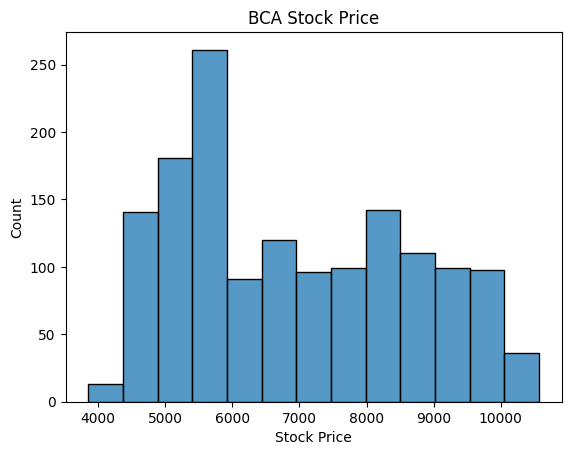

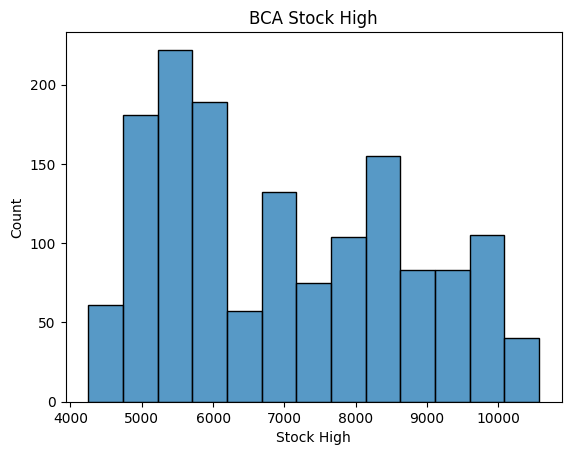

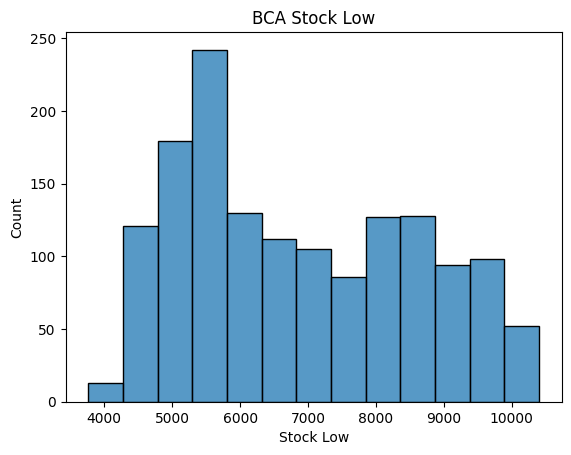

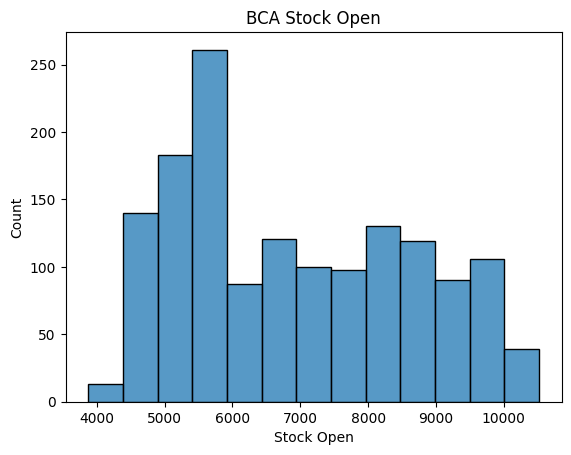

In [11]:
for i in numeric_df :
    sns.histplot(numeric_df[i])
    plt.title('BCA ' + i)
    plt.show()

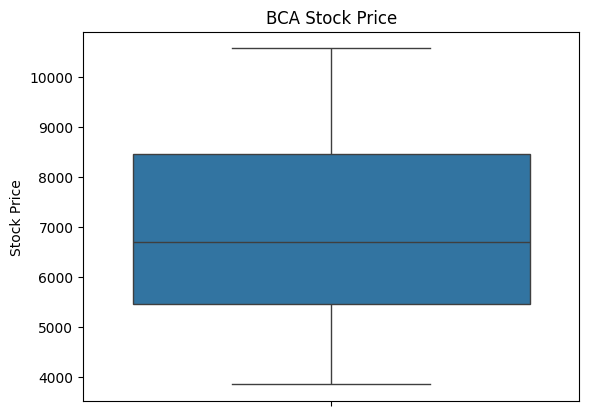

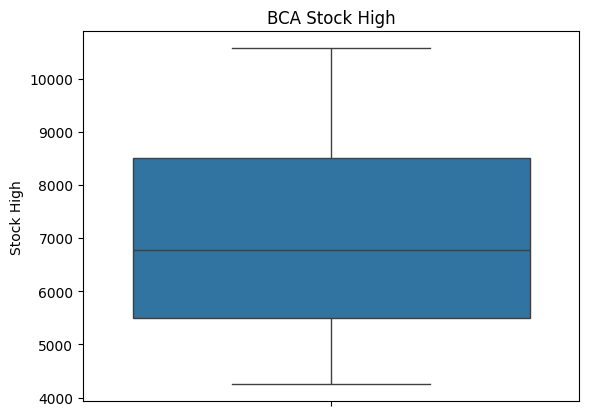

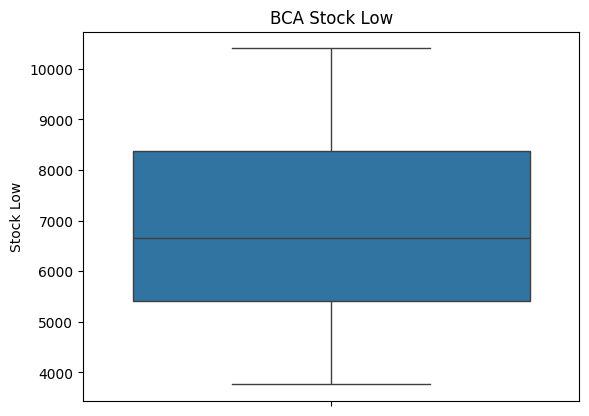

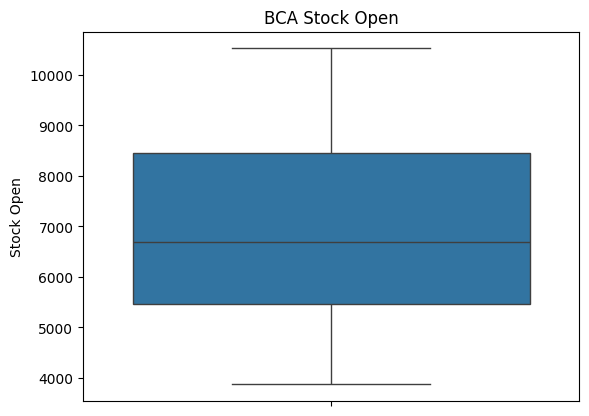

In [12]:
for i in numeric_df :
    sns.boxplot(numeric_df[i])
    plt.title('BCA '+i)
    plt.show()

# Inflation

In [11]:
inflasi = pd.read_excel ('Data Inflasi.xlsx')
inflasi

,No,Periode,Data Inflasi
0,1,Januari 2025,0.76 %
1,2,Desember 2024,1.57 %
2,3,November 2024,1.55 %
3,4,Oktober 2024,1.71 %
4,5,September 2024,1.84 %
...,...,...,...
68,69,Mei 2019,3.32 %
69,70,April 2019,2.83 %
70,71,Maret 2019,2.48 %
71,72,Februari 2019,2.57 %


In [12]:
inflasi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73 entries, 0 to 72
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   No            73 non-null     int64 
 1   Periode       73 non-null     object
 2   Data Inflasi  73 non-null     object
dtypes: int64(1), object(2)
memory usage: 1.8+ KB


In [13]:
inflasi.rename(columns={'Periode' : 'Date', 
                                 'Data Inflasi' : 'Inflasi'},inplace=True)

inflasi = inflasi.drop(columns=['No'])

# Mapping nama bulan Indonesia ke Inggris
month_mapping = {
    'Januari': 'January', 'Februari': 'February', 'Maret': 'March',
    'April': 'April', 'Mei': 'May', 'Juni': 'June',
    'Juli': 'July', 'Agustus': 'August', 'September': 'September',
    'Oktober': 'October', 'November': 'November', 'Desember': 'December'
}

# Mengganti nama bulan ke bahasa Inggris
inflasi['Date'] = inflasi['Date'].replace(month_mapping, regex=True)

# Konversi ke format datetime (defaultnya YYYY-MM-DD dengan tanggal 1)
inflasi['Date'] = pd.to_datetime(inflasi['Date'], format='%B %Y')

# Mengubah format 
inflasi['Inflasi'] = inflasi['Inflasi'].str.replace('%', '').astype(float) / 100

inflasi

,Date,Inflasi
0,2025-01-01,0.0076
1,2024-12-01,0.0157
2,2024-11-01,0.0155
3,2024-10-01,0.0171
4,2024-09-01,0.0184
...,...,...
68,2019-05-01,0.0332
69,2019-04-01,0.0283
70,2019-03-01,0.0248
71,2019-02-01,0.0257


In [14]:
inflasi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73 entries, 0 to 72
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     73 non-null     datetime64[ns]
 1   Inflasi  73 non-null     float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 1.3 KB


In [15]:
inflasi[['Inflasi']].describe()

,Inflasi
count,73.000000
mean,0.027753
std,0.012395
min,0.007600
25%,0.016800
50%,0.026400
75%,0.033200
max,0.059500


In [16]:
inflasi.isna().sum()

Date       0
Inflasi    0
dtype: int64

In [17]:
inflasi.duplicated().sum()

0

In [18]:
import plotly.express as px

# Buat line chart interaktif
fig = px.line(inflasi, x='Date', y='Inflasi', title='Inflation', markers=True)
fig.show()


C:\Users\zakyf\anaconda3\lib\site-packages\_plotly_utils\basevalidators.py:106: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



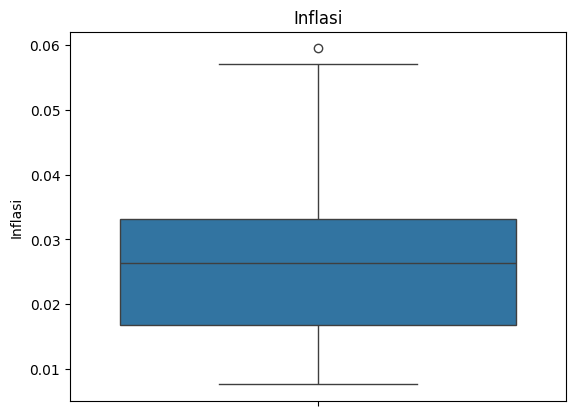

In [20]:
sns.boxplot(inflasi['Inflasi'])
plt.title('Inflasi')
plt.show()

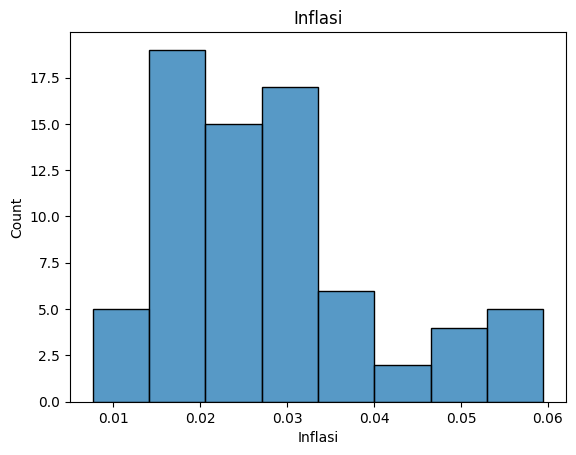

In [21]:
sns.histplot(inflasi['Inflasi'])
plt.title('Inflasi')
plt.show()

# Currency Exchange Data

In [22]:
# Collection of Currency Exchange Data
import yfinance as yf

ticker = "USDIDR=X"  
exchange = yf.download(ticker, start="2019-01-01", end="2025-01-31")

exchange.to_csv("USDIDR_historical.csv")

print(exchange.head())


In [19]:
exchange = pd.read_csv("USDIDR_historical.csv")
exchange

,Price,Close,High,Low,Open,Volume
0,Ticker,USDIDR=X,USDIDR=X,USDIDR=X,USDIDR=X,USDIDR=X
1,Date,NaN,NaN,NaN,NaN,NaN
2,2019-01-01,14460.0,14460.0,14460.0,14460.0,0
3,2019-01-02,14460.0,14513.0,14373.0,14460.0,0
4,2019-01-03,14409.7001953125,14502.5,14367.900390625,14409.7001953125,0
...,...,...,...,...,...,...
1583,2025-01-24,16230.900390625,16234.0,16090.400390625,16230.900390625,0
1584,2025-01-27,16164.900390625,16234.0,16141.0,16164.900390625,0
1585,2025-01-28,16155.599609375,16246.0,16140.099609375,16155.599609375,0
1586,2025-01-29,15881.2001953125,16269.2998046875,15960.599609375,15881.2001953125,0


In [20]:
exchange.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1588 entries, 0 to 1587
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Price   1588 non-null   object
 1   Close   1587 non-null   object
 2   High    1587 non-null   object
 3   Low     1587 non-null   object
 4   Open    1587 non-null   object
 5   Volume  1587 non-null   object
dtypes: object(6)
memory usage: 74.6+ KB


In [21]:
exchange = exchange.drop([0,1])
exchange = exchange.drop(columns=['Volume','High','Low','Open'])
exchange = exchange.rename(columns={'Price' : 'Date', 'Close' : 'Exchange Price'})

exchange["Exchange Price"] = exchange["Exchange Price"].astype(float) # Konversi ke float
exchange['Date'] = pd.to_datetime(exchange['Date'])  # Konversi ke datetime

exchange

,Date,Exchange Price
2,2019-01-01,14460.000000
3,2019-01-02,14460.000000
4,2019-01-03,14409.700195
5,2019-01-04,14375.400391
6,2019-01-07,14267.000000
...,...,...
1583,2025-01-24,16230.900391
1584,2025-01-27,16164.900391
1585,2025-01-28,16155.599609
1586,2025-01-29,15881.200195


In [22]:
import plotly.express as px

# Buat line chart interaktif
fig = px.line(exchange, x='Date', y='Exchange Price', title='Exchange', markers=True)
fig.show()


C:\Users\zakyf\anaconda3\lib\site-packages\_plotly_utils\basevalidators.py:106: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



In [23]:
exchange.isna().sum()

Date              0
Exchange Price    0
dtype: int64

In [24]:
exchange.duplicated().sum()

0

In [25]:
exchange.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1586 entries, 2 to 1587
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            1586 non-null   datetime64[ns]
 1   Exchange Price  1586 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 24.9 KB


In [26]:
exchange[['Exchange Price']].describe()

,Exchange Price
count,1586.000000
mean,14837.977412
std,710.574814
min,13213.240234
25%,14251.654297
50%,14652.887207
75%,15449.500000
max,16504.800781


In [30]:
numeric_df = exchange.select_dtypes(include=['number'])
numeric_df

,Exchange Price
2,14460.000000
3,14460.000000
4,14409.700195
5,14375.400391
6,14267.000000
...,...
1583,16230.900391
1584,16164.900391
1585,16155.599609
1586,15881.200195


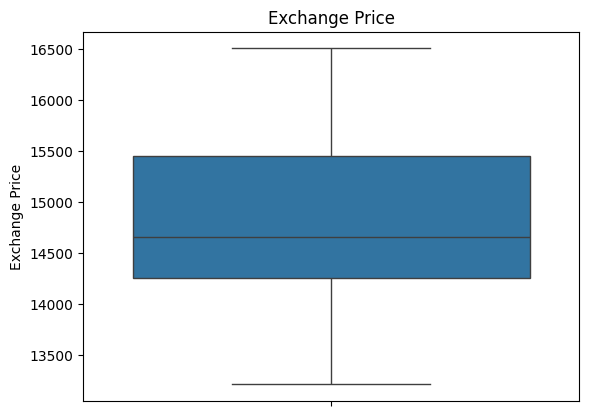

In [31]:
for i in numeric_df :
    sns.boxplot(numeric_df[i])
    plt.title(i)
    plt.show()

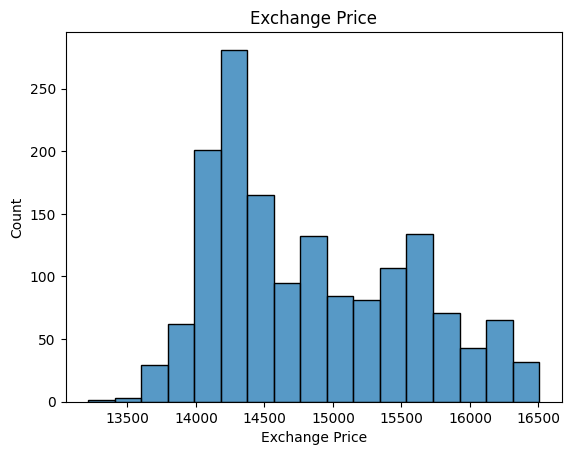

In [32]:
for i in numeric_df :
    sns.histplot(numeric_df[i])
    plt.title(i)
    plt.show()

# Sentiment Analysis

In [4]:
# Lokasi folder
folder_path = "your comments data folder path/*.csv"

# Membaca semua file CSV di folder
all_files = glob.glob(folder_path)
list_df = [pd.read_csv(file) for file in all_files]

# Menggabungkan semua DataFrame menjadi satu
twt = pd.concat(list_df, axis=0, ignore_index=True)
twt


,conversation_id_str,created_at,favorite_count,full_text,id_str,image_url,in_reply_to_screen_name,lang,location,quote_count,reply_count,retweet_count,tweet_url,user_id_str,username
0,1655474319433293824,Mon May 08 07:26:49 +0000 2023,2,It's not a joke. #clear #clearskin #clearanceh...,1655474319433293824,https://pbs.twimg.com/ext_tw_video_thumb/16554...,NaN,en,India,0,0,0,https://x.com/beingshashi190/status/1655474319...,509805779,beingshashi190
1,1806261884355846519,Thu Jun 27 09:42:46 +0000 2024,0,Cara Atasi Lampu Indikator Merah BCA Mobile #x...,1806261884355846519,https://pbs.twimg.com/ext_tw_video_thumb/18062...,NaN,in,Indonesia,0,0,0,https://x.com/alrenzha/status/1806261884355846519,616805548,alrenzha
2,1764866810434961605,Tue Mar 05 04:13:31 +0000 2024,6,BCA kalian gini ga gais? @HaloBCA #bankbca htt...,1764866810434961605,https://pbs.twimg.com/media/GH4RAUwb0AARuSM.jpg,NaN,in,Indonesia,1,14,0,https://x.com/Princess11la/status/176486681043...,1217969024807473157,Princess11la
3,1628021637252628486,Tue Feb 21 13:19:40 +0000 2023,8,Dirgahayu Bank BCA @BankBCA #BCA66 #BankBCA #B...,1628021637252628486,https://pbs.twimg.com/media/FpflC2DaAAAkli2.jpg,NaN,in,"📍SOC - Surakarta, Jawa Tengah",0,6,0,https://x.com/txtfromsoc/status/16280216372526...,1396061587706826752,txtfromsoc
4,1733170452095214048,Fri Dec 08 17:03:31 +0000 2023,0,#bankbca Starting 2023/12/08 17:00 and runs un...,1733170452095214048,https://pbs.twimg.com/media/GA11Vo8WsAAhobZ.jpg,NaN,en,NaN,0,0,0,https://x.com/HashflagNow/status/1733170452095...,1404303087699828742,HashflagNow
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10537,1240523555063730176,Thu Mar 19 07:01:01 +0000 2020,0,@aandhikaz sepanjang januari kemarin 13ribuan ...,1240533721364582400,NaN,andhikaneu,in,Jakarta,0,1,0,https://x.com/Supereza/status/1240533721364582400,78503545,Supereza
10538,1789926655256883444,Mon May 13 07:52:24 +0000 2024,455,Bjkas hissesinde perde formasyonu hala devam e...,1789926655256883444,NaN,NaN,tr,"Bursa, Türkiye",2,35,8,https://x.com/emrah_ulu_dag/status/17899266552...,1256973961985953794,emrah_ulu_dag
10539,1346959501929418753,Wed Jan 06 23:19:06 +0000 2021,295,With this backdrop though KB Securities has lo...,1346959509156229122,NaN,bora_twts,en,NaN,0,3,37,https://x.com/bora_twts/status/134695950915622...,1058344182610300930,bora_twts
10540,1768152307865391426,Thu Mar 14 14:01:25 +0000 2024,205,Sebenernya jual beli saham itu udah biasa gais...,1768276251259879701,NaN,Mooncalfdung,in,She had her own imagintn world,1,4,27,https://x.com/Mooncalfdung/status/176827625125...,546675497,Mooncalfdung


In [5]:
twt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10542 entries, 0 to 10541
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   conversation_id_str      10542 non-null  int64 
 1   created_at               10542 non-null  object
 2   favorite_count           10542 non-null  int64 
 3   full_text                10542 non-null  object
 4   id_str                   10542 non-null  int64 
 5   image_url                3779 non-null   object
 6   in_reply_to_screen_name  1715 non-null   object
 7   lang                     10542 non-null  object
 8   location                 5152 non-null   object
 9   quote_count              10542 non-null  int64 
 10  reply_count              10542 non-null  int64 
 11  retweet_count            10542 non-null  int64 
 12  tweet_url                10542 non-null  object
 13  user_id_str              10542 non-null  int64 
 14  username                 7975 non-null

In [6]:
twt['Date'] = pd.to_datetime(twt['created_at'], format='%a %b %d %H:%M:%S %z %Y').dt.strftime('%Y-%m-%d')
twt['Date'] = pd.to_datetime(twt['Date'])
twt = twt[['Date', 'id_str','full_text']]
twt

,Date,id_str,full_text
0,2023-05-08,1655474319433293824,It's not a joke. #clear #clearskin #clearanceh...
1,2024-06-27,1806261884355846519,Cara Atasi Lampu Indikator Merah BCA Mobile #x...
2,2024-03-05,1764866810434961605,BCA kalian gini ga gais? @HaloBCA #bankbca htt...
3,2023-02-21,1628021637252628486,Dirgahayu Bank BCA @BankBCA #BCA66 #BankBCA #B...
4,2023-12-08,1733170452095214048,#bankbca Starting 2023/12/08 17:00 and runs un...
...,...,...,...
10537,2020-03-19,1240533721364582400,@aandhikaz sepanjang januari kemarin 13ribuan ...
10538,2024-05-13,1789926655256883444,Bjkas hissesinde perde formasyonu hala devam e...
10539,2021-01-06,1346959509156229122,With this backdrop though KB Securities has lo...
10540,2024-03-14,1768276251259879701,Sebenernya jual beli saham itu udah biasa gais...


In [7]:
twt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10542 entries, 0 to 10541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       10542 non-null  datetime64[ns]
 1   id_str     10542 non-null  int64         
 2   full_text  10542 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 247.2+ KB


In [8]:
twt.isna().sum()

Date         0
id_str       0
full_text    0
dtype: int64

In [9]:
twt.duplicated().sum()

4248

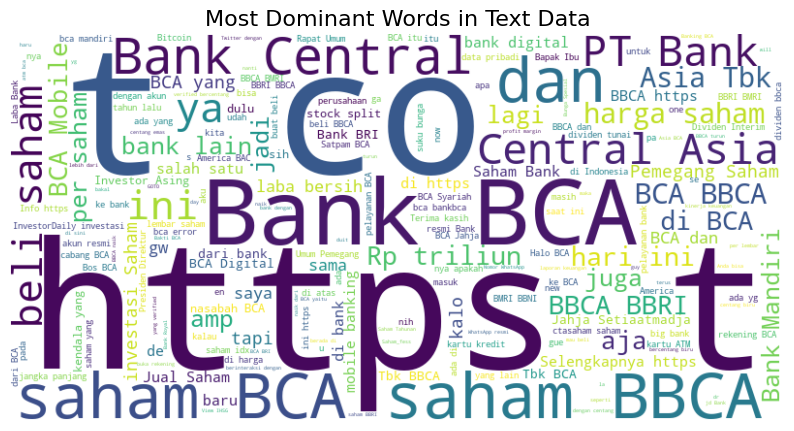

In [10]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(twt['full_text'].astype(str))  # gabungkan semua teks jadi satu string
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Dominant Words in Text Data', fontsize=16)
plt.show()


In [14]:
#Preprocessing

twt = twt.drop_duplicates(subset=['id_str'])
twt.duplicated().sum()

0

In [15]:
twt = twt.sort_values('Date', ascending = True)
twt

In [18]:
teks = twt[['Date','full_text']]
teks = teks.dropna(subset=['full_text'])
teks

,Date,full_text
4408,2019-01-04,Brexit Secretary Stephen Barclay: The extent t...
7547,2019-01-06,Laporan Keuangan Mingguan Baksos - PPM hingga ...
7539,2019-01-06,Bank Dunia memberikan klarifikasi: laporan itu...
8798,2019-01-08,BANK OF AMERICA WELLS FARGO: RIPPLE ENGAGEMENT...
8849,2019-01-08,BANK OF AMERICA WELLS FARGO: RIPPLE ENGAGEMENT...
...,...,...
5669,2025-01-30,BBCA Dibabat Asing AADI Dilahap #infosaham #in...
3393,2025-01-30,ini qris bca lg error kahhhhh min @HaloBCA sta...
2300,2025-01-30,Bbca harusnya naik dulu https://t.co/UKALNqZ10i
3288,2025-01-30,bca masih error? gw habis tf sodara bjil


In [88]:
import string
import re


def remove_single_char_words(text):
    # Pisahkan teks menjadi kata-kata
    words = text.split()
    # Hanya pertahankan kata yang panjangnya lebih dari 1 karakter
    filtered_words = [word for word in words if len(word) > 3]
    # Gabungkan kembali menjadi satu string
    return ' '.join(filtered_words)


def filteringText(text):
    if text is None:  # Check if the input is None
        return ''  # Return empty string if it is None

    text = re.sub(r'@[A-Za-z0-9]+', '', text)
    text = re.sub(r'#[A-Za-z0-9]+', '', text)
    text = re.sub(r'RT[\s]', '', text)
    text = re.sub(r"http\S+", '', text)
    text = text.replace('\n', ' ')
    text = remove_single_char_words(text)
    text = text.strip(' ')

    return text


data_slang = pd.read_excel('kamus_slangword.xlsx')
def replace_slang(text):
    res = ''
    for item in text.split():
        if item in data_slang.slang.values:
            res += data_slang[data_slang['slang'] == item]['formal'].iloc[0]
        else:
            res += item
        res += ' '
    return res


In [19]:
#fix slangwords
teks['full_text'] = teks['full_text'].apply(replace_slang)
teks

In [90]:
#filtering
teks['full_text'] = teks['full_text'].apply(filteringText)
teks

,Date,full_text
4576,2019-01-04,Brexit Secretary Stephen Barclay: extent tapi ...
7547,2019-01-06,Laporan Keuangan Mingguan Baksos hingga Januar...
7539,2019-01-06,Bank Dunia memberikan klarifikasi: laporan sel...
8849,2019-01-08,BANK AMERICA WELLS FARGO: RIPPLE ENGAGEMENT: B...
8798,2019-01-08,BANK AMERICA WELLS FARGO: RIPPLE ENGAGEMENT: B...
...,...,...
10187,2025-01-30,Saham (BBCA) Dihantam Berkali-kali Target Harg...
7824,2025-01-30,pelayanan yang terbaik bagi Bapak/Ibu. Semoga ...
3248,2025-01-30,Wkwk baru komen beberapa detik langsung nyambe...
5669,2025-01-30,BBCA Dibabat Asing AADI Dilahap


In [42]:
from deep_translator import GoogleTranslator
import pandas as pd

# Inisialisasi Google Translator
translator = GoogleTranslator(source='auto', target='en')

# Fungsi untuk menerjemahkan teks
def translate_text(text):
    if pd.isna(text):  # Jika cell kosong, lewati
        return ""
    return translator.translate(text)

# Terapkan fungsi translate ke kolom 'full_text'
teks['full_text'] = teks['full_text'].apply(translate_text)

# Menampilkan hasil
teks


,Date,full_text
3,2019-01-04,Brexit Secretary Stephen Barclay: extent tapi ...
4,2019-01-06,Social Service Weekly Financial Report until J...
5,2019-01-06,The World Bank provided clarification: the rep...
7,2019-01-08,BANK AMERICA WELLS FARGO: RIPPLE ENGAGEMENT: B...
8,2019-01-08,BANK AMERICA WELLS FARGO: RIPPLE ENGAGEMENT: B...
...,...,...
6651,2025-01-30,ERROR
6650,2025-01-30,Error times must really be errors on the first...
6649,2025-01-30,POPULAR NEWS: Opportunity to Buy Cheap Shares ...
6655,2025-01-30,I would be very happy if I gave you shares


In [43]:
import nltk
nltk.download('vader_lexicon')

from nltk.sentiment.vader import SentimentIntensityAnalyzer
import unicodedata

sentiment_i_a = SentimentIntensityAnalyzer()

# Iterate over rows of the original dataframe, not the transposed version
for indexx, row in teks.iterrows():
    try:
        sentence_i = unicodedata.normalize('NFKD', row['full_text'])
        sentence_sentiment = sentiment_i_a.polarity_scores(sentence_i)
        
        # Update the dataframe with sentiment scores
        teks.at[indexx, 'Comp'] = sentence_sentiment['compound']
        teks.at[indexx, 'Negative'] = sentence_sentiment['neg']
        teks.at[indexx, 'Neutral'] = sentence_sentiment['neu']
        teks.at[indexx, 'Positive'] = sentence_sentiment['pos']
    except TypeError:
        print(teks.loc[indexx, 'full_text'])
        print(indexx)

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\zakyf\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [44]:
import pandas as pd

teks['Date'] = pd.to_datetime(teks['Date'])

# Agregasi berdasarkan tanggal
aggregated_data = teks.groupby('Date').agg(
    mean_comp=('Comp', 'mean'),   # Rata-rata skor compound
    # Rata-rata Comp
    median_comp=('Comp', 'median'),       # Median Comp
    mean_negative=('Negative', 'mean'),  # Rata-rata Negative
    mean_neutral=('Neutral', 'mean'),    # Rata-rata Neutral
    mean_positive=('Positive', 'mean')   # Rata-rata Positive
).reset_index()

# Menampilkan hasil agregasi
aggregated_data


,Date,mean_comp,median_comp,mean_negative,mean_neutral,mean_positive
0,2019-01-04,-0.700300,-0.7003,0.185000,0.815000,0.000000
1,2019-01-06,0.038600,0.0386,0.000000,0.980000,0.020000
2,2019-01-08,0.834500,0.8345,0.000000,0.629000,0.371000
3,2019-01-10,0.827100,0.8271,0.000000,0.841000,0.159000
4,2019-01-11,0.812600,0.8126,0.000000,0.637000,0.363000
...,...,...,...,...,...,...
1640,2025-01-26,-0.204440,-0.4019,0.309600,0.649800,0.040800
1641,2025-01-27,-0.072180,-0.4019,0.178400,0.650400,0.171200
1642,2025-01-28,0.200400,0.2263,0.132600,0.629600,0.237800
1643,2025-01-29,0.644400,0.8550,0.000000,0.775500,0.224500


In [45]:
aggregated_data.to_csv('sentiment score bca')

In [59]:
aggregated_data = pd.read_csv('sentiment score bca')
aggregated_data = aggregated_data.drop(columns=['Unnamed: 0','median_comp','mean_negative','mean_neutral','mean_positive'])
aggregated_data = aggregated_data.dropna()
aggregated_data

,Date,mean_comp
0,2019-01-04,-0.690800
1,2019-01-06,-0.113150
2,2019-01-08,0.834500
3,2019-01-10,0.718400
4,2019-01-11,0.812600
...,...,...
1640,2025-01-26,-0.310520
1641,2025-01-27,-0.033980
1642,2025-01-28,0.130700
1643,2025-01-29,0.608500


In [8]:
aggregated_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1645 entries, 0 to 1644
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1645 non-null   object 
 1   mean_comp  1645 non-null   float64
dtypes: float64(1), object(1)
memory usage: 25.8+ KB


In [9]:
aggregated_data['Date'] = pd.to_datetime(aggregated_data['Date'])


In [42]:
df = aggregated_data
for df_merged in [inflasi, exchange, stock]:
    df = pd.merge(df_merged, df, on="Date", how="outer")

df

,Date,Stock Price,Stock High,Stock Low,Stock Open,Exchange Price,Inflasi,mean_comp
0,2019-01-01,4469.358398,4469.358398,4469.358398,4469.358398,14460.000000,0.0282,NaN
1,2019-01-02,4503.737793,4508.035253,4469.358115,4469.358115,14460.000000,NaN,NaN
2,2019-01-03,4452.168945,4486.548628,4396.301960,4469.358787,14409.700195,NaN,NaN
3,2019-01-04,4473.656738,4473.656738,4404.897365,4447.871973,14375.400391,NaN,-0.690800
4,2019-01-06,NaN,NaN,NaN,NaN,NaN,NaN,-0.113150
...,...,...,...,...,...,...,...,...
2010,2025-01-26,NaN,NaN,NaN,NaN,NaN,NaN,-0.310520
2011,2025-01-27,NaN,NaN,NaN,NaN,16164.900391,NaN,-0.033980
2012,2025-01-28,NaN,NaN,NaN,NaN,16155.599609,NaN,0.130700
2013,2025-01-29,NaN,NaN,NaN,NaN,15881.200195,NaN,0.608500


In [43]:
# # Mengisi missing value pada data tipe data float atau integer tepat dengan value sebelumnya.
df['Inflasi'] = df['Inflasi'].fillna(method='ffill')
df[['Stock Price','Stock Open','Stock High','Stock Low']] = df[['Stock Price',
                                                                'Stock Open','Stock High','Stock Low']].fillna(method='ffill')
df['Exchange Price'] = df['Exchange Price'].fillna(method='ffill')
df['mean_comp'] = df['mean_comp'].fillna(method='ffill')
df = df.dropna()
df

C:\Users\zakyf\AppData\Local\Temp\ipykernel_30048\274686097.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Inflasi'] = df['Inflasi'].fillna(method='ffill')
C:\Users\zakyf\AppData\Local\Temp\ipykernel_30048\274686097.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[['Stock Price','Stock Open','Stock High','Stock Low']] = df[['Stock Price','Stock Open','Stock High','Stock Low']].fillna(method='ffill')
C:\Users\zakyf\AppData\Local\Temp\ipykernel_30048\274686097.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Exchange Price'] = df['Exchange Price'].fillna(method='ffill')
C:\Users\zakyf\AppData\Local\Temp\ipykernel_30048\274686097.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will r

,Date,Stock Price,Stock High,Stock Low,Stock Open,Exchange Price,Inflasi,mean_comp
3,2019-01-04,4473.656738,4473.656738,4404.897365,4447.871973,14375.400391,0.0282,-0.690800
4,2019-01-06,4473.656738,4473.656738,4404.897365,4447.871973,14375.400391,0.0282,-0.113150
5,2019-01-07,4508.035645,4576.795006,4508.035645,4525.225485,14267.000000,0.0282,-0.113150
6,2019-01-08,4503.737793,4572.497149,4473.655575,4495.142874,14083.000000,0.0282,0.834500
7,2019-01-09,4516.630859,4572.497844,4490.846097,4555.308003,14138.000000,0.0282,0.834500
...,...,...,...,...,...,...,...,...
2010,2025-01-26,9070.895508,9361.940283,9070.895508,9337.686552,16230.900391,0.0076,-0.310520
2011,2025-01-27,9070.895508,9361.940283,9070.895508,9337.686552,16164.900391,0.0076,-0.033980
2012,2025-01-28,9070.895508,9361.940283,9070.895508,9337.686552,16155.599609,0.0076,0.130700
2013,2025-01-29,9070.895508,9361.940283,9070.895508,9337.686552,15881.200195,0.0076,0.608500


In [49]:
df.duplicated().sum()

0

In [47]:
df.to_csv('data_BBCA.csv')

In [48]:
df = pd.read_csv('data_BBCA.csv')
df

,Unnamed: 0,Date,Stock Price,Stock High,Stock Low,Stock Open,Exchange Price,Inflasi,mean_comp
0,3,2019-01-04,4473.656738,4473.656738,4404.897365,4447.871973,14375.400391,0.0282,-0.690800
1,4,2019-01-06,4473.656738,4473.656738,4404.897365,4447.871973,14375.400391,0.0282,-0.113150
2,5,2019-01-07,4508.035645,4576.795006,4508.035645,4525.225485,14267.000000,0.0282,-0.113150
3,6,2019-01-08,4503.737793,4572.497149,4473.655575,4495.142874,14083.000000,0.0282,0.834500
4,7,2019-01-09,4516.630859,4572.497844,4490.846097,4555.308003,14138.000000,0.0282,0.834500
...,...,...,...,...,...,...,...,...,...
2007,2010,2025-01-26,9070.895508,9361.940283,9070.895508,9337.686552,16230.900391,0.0076,-0.310520
2008,2011,2025-01-27,9070.895508,9361.940283,9070.895508,9337.686552,16164.900391,0.0076,-0.033980
2009,2012,2025-01-28,9070.895508,9361.940283,9070.895508,9337.686552,16155.599609,0.0076,0.130700
2010,2013,2025-01-29,9070.895508,9361.940283,9070.895508,9337.686552,15881.200195,0.0076,0.608500


# LSTM

In [24]:
import pandas as pd
import numpy as np
import matplotlib
import glob
import re
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense, Activation, Flatten, LSTM
from keras.optimizers import Adam

In [25]:
df = pd.read_csv('data_BBCA.csv')
df = df.drop(columns=['Unnamed: 0'])
df

,Date,Stock Price,Stock High,Stock Low,Stock Open,Exchange Price,Inflasi,mean_comp
0,2019-01-04,4473.656738,4473.656738,4404.897365,4447.871973,14375.400391,0.0282,-0.690800
1,2019-01-06,4473.656738,4473.656738,4404.897365,4447.871973,14375.400391,0.0282,-0.113150
2,2019-01-07,4508.035645,4576.795006,4508.035645,4525.225485,14267.000000,0.0282,-0.113150
3,2019-01-08,4503.737793,4572.497149,4473.655575,4495.142874,14083.000000,0.0282,0.834500
4,2019-01-09,4516.630859,4572.497844,4490.846097,4555.308003,14138.000000,0.0282,0.834500
...,...,...,...,...,...,...,...,...
2007,2025-01-26,9070.895508,9361.940283,9070.895508,9337.686552,16230.900391,0.0076,-0.310520
2008,2025-01-27,9070.895508,9361.940283,9070.895508,9337.686552,16164.900391,0.0076,-0.033980
2009,2025-01-28,9070.895508,9361.940283,9070.895508,9337.686552,16155.599609,0.0076,0.130700
2010,2025-01-29,9070.895508,9361.940283,9070.895508,9337.686552,15881.200195,0.0076,0.608500


In [26]:
import plotly.express as px

# Buat line chart interaktif
fig = px.line(df, x='Date', y='Stock Price', title='Stock Price Over Time', markers=True)
fig.show()


In [27]:
import numpy as np
import random
import os
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.metrics import mean_absolute_error
import tensorflow as tf

# Step 1: Set Seed (Reproducibility)
seed_value = 42
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)

# Memastikan TensorFlow berjalan secara deterministik
os.environ['PYTHONHASHSEED'] = str(seed_value)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'  # Jika menggunakan GPU

In [28]:
train_size = int(0.7 * len(df))
val_size = int(0.2 * len(df))
test_size = len(df) - train_size - val_size

train_data = df.iloc[:train_size].reset_index(drop=True)
val_data = df.iloc[train_size:train_size + val_size].reset_index(drop=True)
test_data = df.iloc[train_size + val_size:].reset_index(drop=True)


In [29]:
from sklearn.preprocessing import MinMaxScaler

# Fitur dan target
feature_cols = ['Stock Open', 'Stock High', 'Stock Low', 'Inflasi', 'Exchange Price','mean_comp']
target_col = 'Stock Price'

# Inisialisasi scaler
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# Fit hanya ke data train (untuk menghindari leakage)
X_train_scaled = scaler_X.fit_transform(train_data[feature_cols])
X_val_scaled = scaler_X.transform(val_data[feature_cols])
X_test_scaled = scaler_X.transform(test_data[feature_cols])

y_train_scaled = scaler_y.fit_transform(train_data[[target_col]])
y_val_scaled = scaler_y.transform(val_data[[target_col]])
y_test_scaled = scaler_y.transform(test_data[[target_col]])


In [30]:
# reshape ke (samples, time_steps=1, features)
train_X = X_train_scaled
val_X = X_val_scaled
test_X = X_test_scaled

train_y = y_train_scaled
val_y = y_val_scaled
test_y = y_test_scaled


In [31]:
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

train_X = X_train_scaled
val_X = X_val_scaled
test_X = X_test_scaled

train_y = y_train_scaled
val_y = y_val_scaled
test_y = y_test_scaled

look_back = 20
batch_size = 16

train_generator = TimeseriesGenerator(train_X, train_y,
                                      length=look_back, batch_size=batch_size)
val_generator = TimeseriesGenerator(val_X, val_y,
                                    length=look_back, batch_size=batch_size)
test_generator = TimeseriesGenerator(test_X, test_y,
                                     length=look_back, batch_size=batch_size)


In [32]:
from keras.models import Sequential
from keras.layers import LSTM, Dense

n_features = len(feature_cols)

model = Sequential()
model.add(LSTM(96, input_shape=(look_back, n_features)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')


from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,             
    restore_best_weights=True 
)

history = model.fit(
    train_generator,
    epochs=100,
    validation_data=val_generator,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/100
87/87 [==============================] - 3s 17ms/step - loss: 0.0077 - val_loss: 0.0111
Epoch 2/100
87/87 [==============================] - 1s 12ms/step - loss: 0.0025 - val_loss: 0.0048
Epoch 3/100
87/87 [==============================] - 1s 11ms/step - loss: 0.0018 - val_loss: 8.3632e-04
Epoch 4/100
87/87 [==============================] - 1s 11ms/step - loss: 0.0011 - val_loss: 8.8665e-04
Epoch 5/100
87/87 [==============================] - 1s 11ms/step - loss: 0.0016 - val_loss: 0.0108
Epoch 6/100
87/87 [==============================] - 1s 11ms/step - loss: 0.0012 - val_loss: 0.0014
Epoch 7/100
87/87 [==============================] - 1s 11ms/step - loss: 9.4444e-04 - val_loss: 0.0027
Epoch 8/100
87/87 [==============================] - 1s 11ms/step - loss: 7.8657e-04 - val_loss: 8.2596e-04
Epoch 9/100
87/87 [==============================] - 1s 11ms/step - loss: 9.4297e-04 - val_loss: 0.0157
Epoch 10/100
87/87 [==============================] - 1s 11ms/step - loss: 8

Epoch 78/100
87/87 [==============================] - 1s 10ms/step - loss: 3.9986e-04 - val_loss: 6.1384e-04
Epoch 79/100
87/87 [==============================] - 1s 10ms/step - loss: 4.7117e-04 - val_loss: 4.9069e-04
Epoch 80/100
87/87 [==============================] - 1s 10ms/step - loss: 3.9491e-04 - val_loss: 4.8774e-04
Epoch 81/100
87/87 [==============================] - 1s 10ms/step - loss: 3.8544e-04 - val_loss: 6.4743e-04
Epoch 82/100
87/87 [==============================] - 1s 10ms/step - loss: 4.0152e-04 - val_loss: 4.8542e-04
Epoch 83/100
87/87 [==============================] - 1s 10ms/step - loss: 3.9625e-04 - val_loss: 6.0368e-04
Epoch 84/100
87/87 [==============================] - 1s 10ms/step - loss: 4.0467e-04 - val_loss: 4.9111e-04
Epoch 85/100
87/87 [==============================] - 1s 10ms/step - loss: 3.6709e-04 - val_loss: 4.9226e-04
Epoch 86/100
87/87 [==============================] - 1s 11ms/step - loss: 3.9408e-04 - val_loss: 9.9165e-04
Epoch 87/100
87/87 

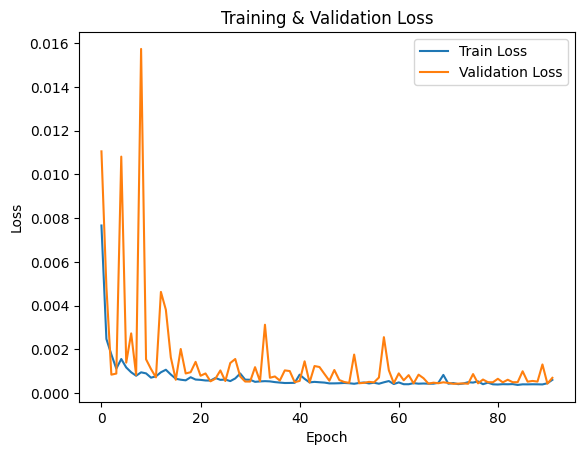

In [33]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training & Validation Loss')
plt.show()

In [36]:
from sklearn.metrics import mean_absolute_error
import numpy as np

# Contoh prediksi dari test_generator
pred_scaled = model.predict(test_generator)

# Inverse scale prediksi dan ground truth
y_pred = scaler_y.inverse_transform(pred_scaled)
y_true = scaler_y.inverse_transform(test_y[look_back:])

# Metrik evaluasi
mae = mean_absolute_error(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100  # dalam persen

# Print hasil
print(f"📊 Evaluation Metrics:")
print(f"MAE  : {mae:.4f}")
print(f"MAPE : {mape}")



12/12 [==============================] - 0s 3ms/step
📊 Evaluation Metrics:
MAE  : 100.8387
MAPE : 1.0245067325595552


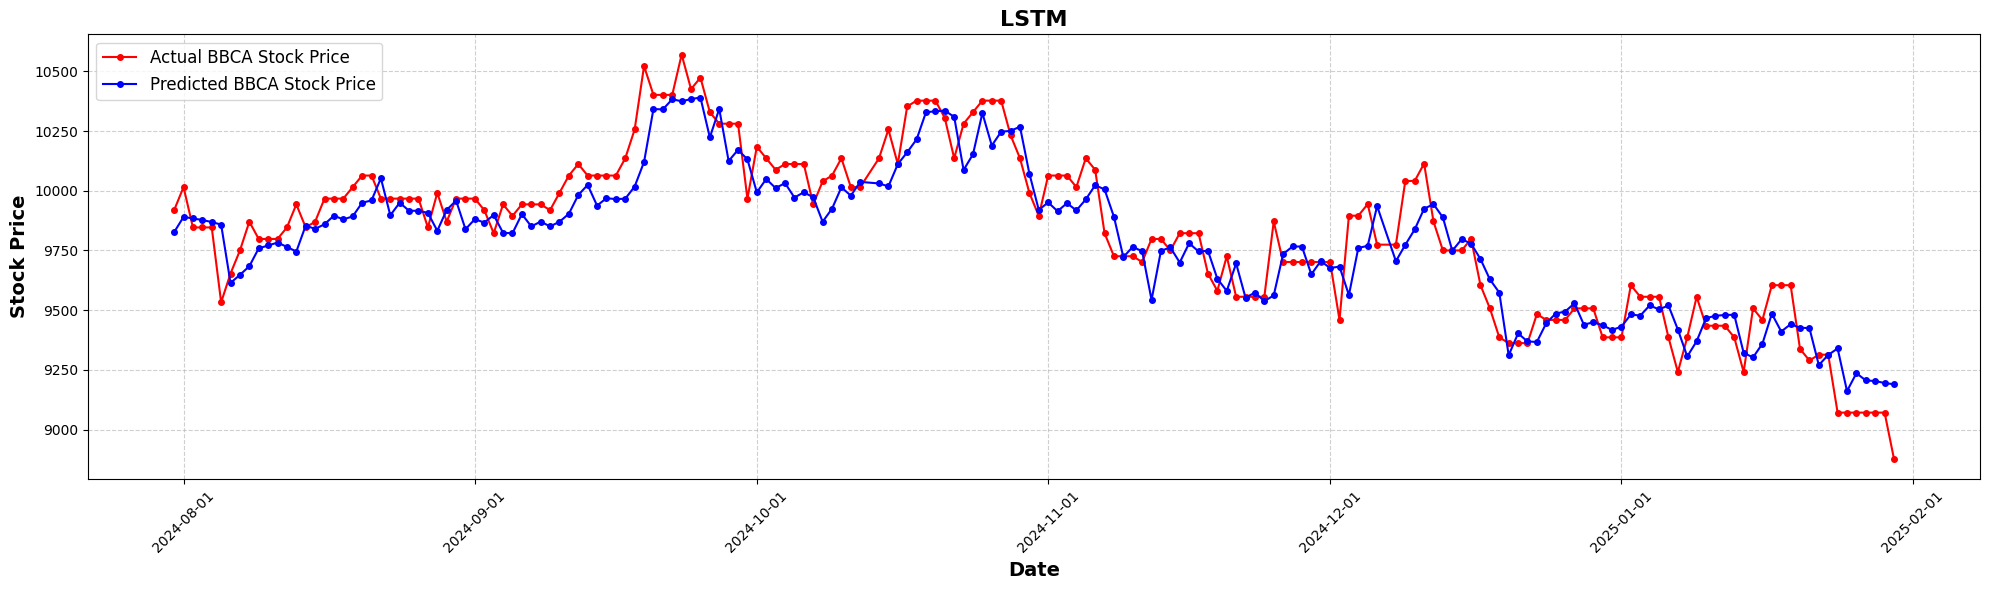

In [35]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# Konversi kolom 'Date' ke format datetime jika belum
test_data['Date'] = pd.to_datetime(test_data['Date'])

# Jika kamu menggunakan TimeseriesGenerator dengan look_back, offset perlu disesuaikan
offset = look_back  # Biasanya 20

# Inverse scale prediksi dan ground truth
y_pred = scaler_y.inverse_transform(pred_scaled)
y_true = scaler_y.inverse_transform(test_y[look_back:])

plot_dates = test_data['Date'][offset:].reset_index(drop=True)

# Buat plot
plt.figure(figsize=(20, 6))

# Real values (y_true sudah di-inverse transform)
plt.plot(plot_dates, y_true, 'o-', color='red',
         linewidth=1.5, markersize=4, label="Actual BBCA Stock Price")

# Predicted values
plt.plot(plot_dates, y_pred, 'o-', color='blue',
         linewidth=1.5, markersize=4, label="Predicted BBCA Stock Price")

# Format sumbu dan tampilan
plt.xlabel("Date", fontsize=14, fontweight='bold')
plt.ylabel("Stock Price", fontsize=14, fontweight='bold')
plt.title("LSTM", fontsize=16, fontweight='bold')

plt.xticks(rotation=45)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())

plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
plt.show()


# CNN

In [37]:
import pandas as pd 
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense, Activation, Flatten
from keras.optimizers import Adam
import glob
import re

In [38]:
df = pd.read_csv('data_BBCA.csv')
df = df.drop(columns=['Unnamed: 0'])
df

,Date,Stock Price,Stock High,Stock Low,Stock Open,Exchange Price,Inflasi,mean_comp
0,2019-01-04,4473.656738,4473.656738,4404.897365,4447.871973,14375.400391,0.0282,-0.690800
1,2019-01-06,4473.656738,4473.656738,4404.897365,4447.871973,14375.400391,0.0282,-0.113150
2,2019-01-07,4508.035645,4576.795006,4508.035645,4525.225485,14267.000000,0.0282,-0.113150
3,2019-01-08,4503.737793,4572.497149,4473.655575,4495.142874,14083.000000,0.0282,0.834500
4,2019-01-09,4516.630859,4572.497844,4490.846097,4555.308003,14138.000000,0.0282,0.834500
...,...,...,...,...,...,...,...,...
2007,2025-01-26,9070.895508,9361.940283,9070.895508,9337.686552,16230.900391,0.0076,-0.310520
2008,2025-01-27,9070.895508,9361.940283,9070.895508,9337.686552,16164.900391,0.0076,-0.033980
2009,2025-01-28,9070.895508,9361.940283,9070.895508,9337.686552,16155.599609,0.0076,0.130700
2010,2025-01-29,9070.895508,9361.940283,9070.895508,9337.686552,15881.200195,0.0076,0.608500


In [39]:
import numpy as np
import random
import os
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

# Step 1: Set Seed (Reproducibility)
seed_value = 42
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)

# Memastikan TensorFlow berjalan secara deterministik
os.environ['PYTHONHASHSEED'] = str(seed_value)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'  # Jika menggunakan GPU

In [40]:
train_size = int(0.7 * len(df))
val_size = int(0.2 * len(df))
test_size = len(df) - train_size - val_size  # Sisa untuk test

# Pisahkan data tanpa shuffle
train_data = df.iloc[:train_size].reset_index(drop=True)
val_data = df.iloc[train_size:train_size + val_size].reset_index(drop=True)
test_data = df.iloc[train_size + val_size:].reset_index(drop=True)

In [41]:
from sklearn.preprocessing import MinMaxScaler

# Fitur dan target
feature_cols = ['Stock Open', 'Stock High', 'Stock Low', 'Inflasi', 'Exchange Price','mean_comp']
target_col = 'Stock Price'

# Inisialisasi scaler
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# Fit hanya ke data train (untuk menghindari leakage)
X_train_scaled = scaler_X.fit_transform(train_data[feature_cols])
X_val_scaled = scaler_X.transform(val_data[feature_cols])
X_test_scaled = scaler_X.transform(test_data[feature_cols])

y_train_scaled = scaler_y.fit_transform(train_data[[target_col]])
y_val_scaled = scaler_y.transform(val_data[[target_col]])
y_test_scaled = scaler_y.transform(test_data[[target_col]])


In [42]:
# reshape ke (samples, time_steps=1, features)
train_X = X_train_scaled
val_X = X_val_scaled
test_X = X_test_scaled

train_y = y_train_scaled
val_y = y_val_scaled
test_y = y_test_scaled


In [43]:
# Conv1D = Lapisan dalam jaringan saraf konvolusional (CNN)

from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
from keras.models import Sequential
from keras.layers import Dense, Conv1D, Flatten

look_back = 20
batch_size = 16

train_generator = TimeseriesGenerator(train_X, train_y,
                                      length=look_back, batch_size=batch_size)
val_generator = TimeseriesGenerator(val_X, val_y,
                                    length=look_back, batch_size=batch_size)
test_generator = TimeseriesGenerator(test_X, test_y,
                                     length=look_back, batch_size=batch_size)

# Defining CNN model for time series forecasting
n_filters = 128
kernel_size = 3
n_features = len(feature_cols)
model = Sequential()
model.add(Conv1D(filters=n_filters, kernel_size=kernel_size, activation='relu', input_shape=(look_back, n_features)))
model.add(Flatten())
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=30,              
    restore_best_weights=True
)

history = model.fit(
    train_generator,
    epochs=100,
    validation_data=val_generator,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/100
87/87 [==============================] - 1s 3ms/step - loss: 0.0250 - val_loss: 0.0074
Epoch 2/100
87/87 [==============================] - 0s 2ms/step - loss: 0.0039 - val_loss: 0.0142
Epoch 3/100
87/87 [==============================] - 0s 2ms/step - loss: 0.0033 - val_loss: 0.0024
Epoch 4/100
87/87 [==============================] - 0s 2ms/step - loss: 0.0021 - val_loss: 0.0013
Epoch 5/100
87/87 [==============================] - 0s 2ms/step - loss: 0.0029 - val_loss: 0.0120
Epoch 6/100
87/87 [==============================] - 0s 2ms/step - loss: 0.0018 - val_loss: 0.0060
Epoch 7/100
87/87 [==============================] - 0s 2ms/step - loss: 0.0017 - val_loss: 0.0026
Epoch 8/100
87/87 [==============================] - 0s 2ms/step - loss: 0.0015 - val_loss: 0.0026
Epoch 9/100
87/87 [==============================] - 0s 2ms/step - loss: 0.0022 - val_loss: 0.0562
Epoch 10/100
87/87 [==============================] - 0s 2ms/step - loss: 0.0024 - val_loss: 0.0022
Epoch 11/

87/87 [==============================] - 0s 2ms/step - loss: 5.6675e-04 - val_loss: 0.0013
Epoch 81/100
87/87 [==============================] - 0s 2ms/step - loss: 5.0610e-04 - val_loss: 6.8916e-04
Epoch 82/100
87/87 [==============================] - 0s 2ms/step - loss: 5.1232e-04 - val_loss: 0.0011
Epoch 83/100
87/87 [==============================] - 0s 2ms/step - loss: 6.6781e-04 - val_loss: 0.0011
Epoch 84/100
87/87 [==============================] - 0s 2ms/step - loss: 9.7980e-04 - val_loss: 0.0013
Epoch 85/100
87/87 [==============================] - 0s 2ms/step - loss: 5.4892e-04 - val_loss: 5.8601e-04
Epoch 86/100
87/87 [==============================] - 0s 2ms/step - loss: 5.8655e-04 - val_loss: 8.2552e-04
Epoch 87/100
87/87 [==============================] - 0s 2ms/step - loss: 5.0053e-04 - val_loss: 9.0863e-04
Epoch 88/100
87/87 [==============================] - 0s 2ms/step - loss: 5.3905e-04 - val_loss: 6.4864e-04
Epoch 89/100
87/87 [==============================] - 0s 

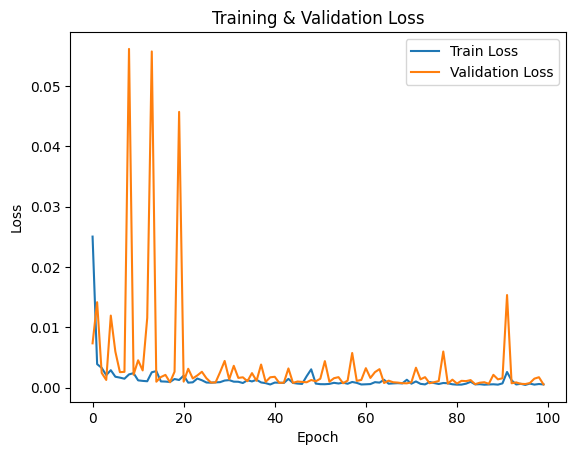

In [44]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training & Validation Loss')
plt.show()


In [46]:
from sklearn.metrics import mean_absolute_error
import numpy as np

# Contoh prediksi dari test_generator
pred_scaled = model.predict(test_generator)

# Inverse scale prediksi dan ground truth
y_pred = scaler_y.inverse_transform(pred_scaled)
y_true = scaler_y.inverse_transform(test_y[look_back:])

# Metrik evaluasi
mae = mean_absolute_error(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100  # dalam persen

# Print hasil
print(f"📊 Evaluation Metrics:")
print(f"MAE  : {mae:.4f}")
print(f"MAPE : {mape:.2f}%")
# print(f"R2 Score : {r2:.2f}%")


12/12 [==============================] - 0s 1ms/step
📊 Evaluation Metrics:
MAE  : 108.7902
MAPE : 1.11%


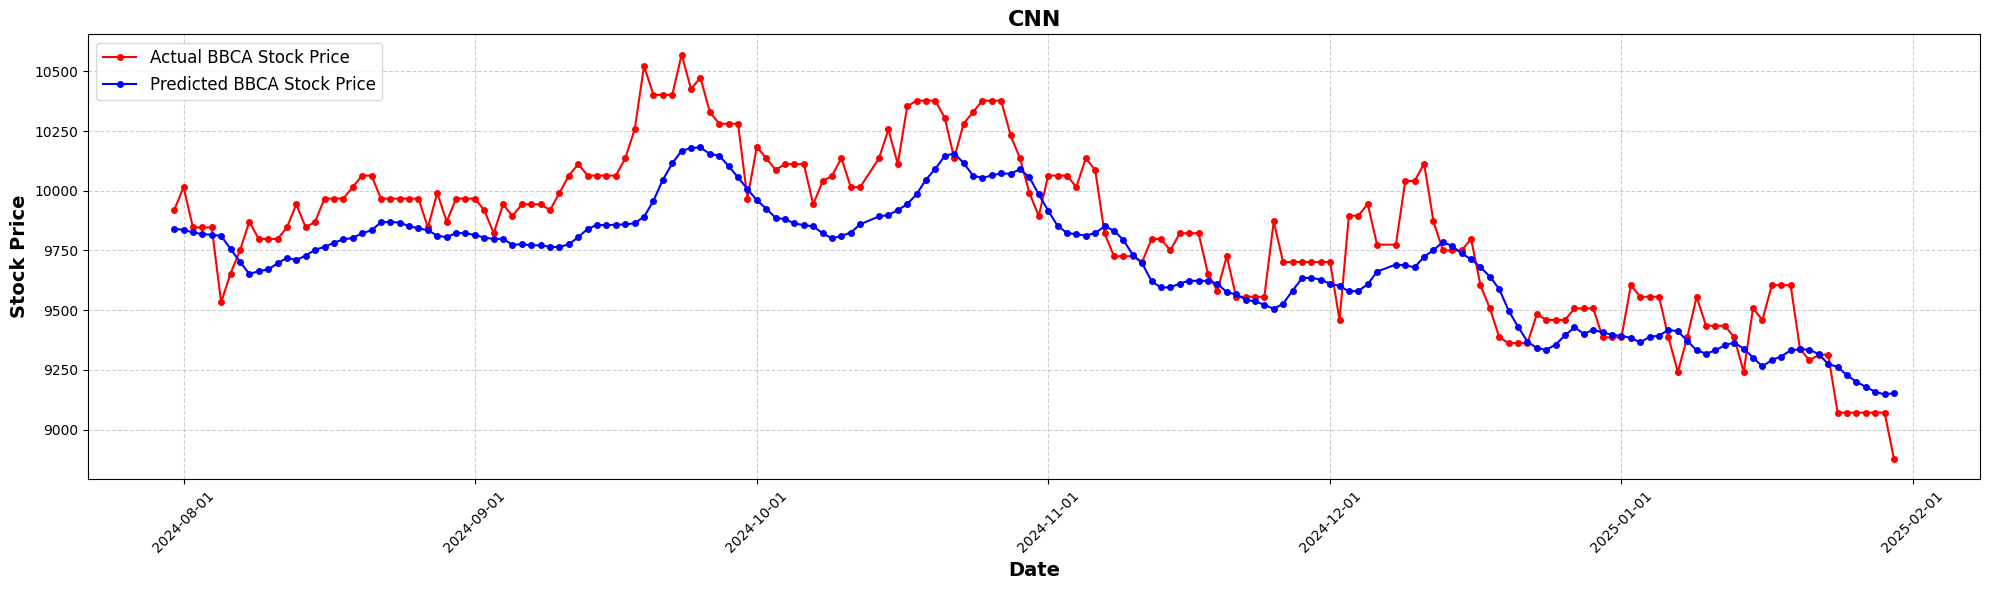

In [58]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# Konversi kolom 'Date' ke format datetime jika belum
test_data['Date'] = pd.to_datetime(test_data['Date'])

offset = look_back  # Biasanya 20

# Prediksi hasil model sudah di-inverse transform
y_pred = scaler_y.inverse_transform(pred_scaled)
y_true = scaler_y.inverse_transform(test_y[offset:])

plot_dates = test_data['Date'][offset:].reset_index(drop=True)

# Buat plot
plt.figure(figsize=(20, 6))

# Real values (y_true sudah di-inverse transform)
plt.plot(plot_dates, y_true, 'o-', color='red',
         linewidth=1.5, markersize=4, label="Actual BBCA Stock Price")

# Predicted values
plt.plot(plot_dates, y_pred, 'o-', color='blue',
         linewidth=1.5, markersize=4, label="Predicted BBCA Stock Price")

# Format sumbu dan tampilan
plt.xlabel("Date", fontsize=14, fontweight='bold')
plt.ylabel("Stock Price", fontsize=14, fontweight='bold')
plt.title("CNN", fontsize=16, fontweight='bold')

plt.xticks(rotation=45)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())

plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
plt.show()


# CNN-LSTM

In [60]:
import pandas as pd 
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense, Activation, Flatten, LSTM
from keras.optimizers import Adam
import glob
import re

In [61]:
df = pd.read_csv('data_BBCA.csv')
df = df.drop(columns=['Unnamed: 0'])
df

,Date,Stock Price,Stock High,Stock Low,Stock Open,Exchange Price,Inflasi,mean_comp
0,2019-01-04,4473.656738,4473.656738,4404.897365,4447.871973,14375.400391,0.0282,-0.690800
1,2019-01-06,4473.656738,4473.656738,4404.897365,4447.871973,14375.400391,0.0282,-0.113150
2,2019-01-07,4508.035645,4576.795006,4508.035645,4525.225485,14267.000000,0.0282,-0.113150
3,2019-01-08,4503.737793,4572.497149,4473.655575,4495.142874,14083.000000,0.0282,0.834500
4,2019-01-09,4516.630859,4572.497844,4490.846097,4555.308003,14138.000000,0.0282,0.834500
...,...,...,...,...,...,...,...,...
2007,2025-01-26,9070.895508,9361.940283,9070.895508,9337.686552,16230.900391,0.0076,-0.310520
2008,2025-01-27,9070.895508,9361.940283,9070.895508,9337.686552,16164.900391,0.0076,-0.033980
2009,2025-01-28,9070.895508,9361.940283,9070.895508,9337.686552,16155.599609,0.0076,0.130700
2010,2025-01-29,9070.895508,9361.940283,9070.895508,9337.686552,15881.200195,0.0076,0.608500


In [62]:
import numpy as np
import random
import os
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

# Step 1: Set Seed (Reproducibility)
seed_value = 42
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)

# Memastikan TensorFlow berjalan secara deterministik
os.environ['PYTHONHASHSEED'] = str(seed_value)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'  # Jika menggunakan GPU

In [63]:
train_size = int(0.7 * len(df))
val_size = int(0.2 * len(df))
test_size = len(df) - train_size - val_size

train_data = df.iloc[:train_size].reset_index(drop=True)
val_data = df.iloc[train_size:train_size + val_size].reset_index(drop=True)
test_data = df.iloc[train_size + val_size:].reset_index(drop=True)


In [64]:
from sklearn.preprocessing import MinMaxScaler

# Fitur dan target
feature_cols = ['Stock Open', 'Stock High', 'Stock Low', 'Inflasi', 'Exchange Price','mean_comp']
target_col = 'Stock Price'

# Inisialisasi scaler
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# Fit hanya ke data train (untuk menghindari leakage)
X_train_scaled = scaler_X.fit_transform(train_data[feature_cols])
X_val_scaled = scaler_X.transform(val_data[feature_cols])
X_test_scaled = scaler_X.transform(test_data[feature_cols])

y_train_scaled = scaler_y.fit_transform(train_data[[target_col]])
y_val_scaled = scaler_y.transform(val_data[[target_col]])
y_test_scaled = scaler_y.transform(test_data[[target_col]])


In [65]:
# reshape ke (samples, time_steps=1, features)
train_X = X_train_scaled
val_X = X_val_scaled
test_X = X_test_scaled

train_y = y_train_scaled
val_y = y_val_scaled
test_y = y_test_scaled


In [66]:
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
from keras.models import Sequential
from keras.layers import Dense, Conv1D, LSTM, Flatten

look_back = 20
batch_size = 16

train_generator = TimeseriesGenerator(train_X, train_y,
                                      length=look_back, batch_size=batch_size)
val_generator = TimeseriesGenerator(val_X, val_y,
                                    length=look_back, batch_size=batch_size)
test_generator = TimeseriesGenerator(test_X, test_y,
                                     length=look_back, batch_size=batch_size)

# # Defining hybrid CNN-LSTM model for time series forecasting
n_filters = 128
n_features = len(feature_cols)
kernel_size = 3
model = Sequential()
model.add(Conv1D(filters=n_filters, kernel_size=kernel_size, activation='relu',input_shape=(look_back, n_features)))
model.add(LSTM(64, input_shape=(look_back, n_features)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,              
    restore_best_weights=True 
)

history = model.fit(
    train_generator,
    epochs=100,
    validation_data=val_generator,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/100
87/87 [==============================] - 2s 11ms/step - loss: 0.0075 - val_loss: 0.0138
Epoch 2/100
87/87 [==============================] - 1s 8ms/step - loss: 0.0016 - val_loss: 0.0014
Epoch 3/100
87/87 [==============================] - 1s 7ms/step - loss: 0.0018 - val_loss: 0.0053
Epoch 4/100
87/87 [==============================] - 1s 8ms/step - loss: 0.0020 - val_loss: 0.0025
Epoch 5/100
87/87 [==============================] - 1s 8ms/step - loss: 0.0019 - val_loss: 0.0148
Epoch 6/100
87/87 [==============================] - 1s 8ms/step - loss: 0.0011 - val_loss: 0.0010
Epoch 7/100
87/87 [==============================] - 1s 8ms/step - loss: 9.7316e-04 - val_loss: 0.0045
Epoch 8/100
87/87 [==============================] - 1s 7ms/step - loss: 8.2520e-04 - val_loss: 0.0023
Epoch 9/100
87/87 [==============================] - 1s 7ms/step - loss: 9.4512e-04 - val_loss: 0.0138
Epoch 10/100
87/87 [==============================] - 1s 7ms/step - loss: 0.0012 - val_loss: 0.0

In [67]:
from sklearn.metrics import mean_absolute_error
import numpy as np

# Contoh prediksi dari test_generator
pred_scaled = model.predict(test_generator)

# Inverse scale prediksi dan ground truth
y_pred = scaler_y.inverse_transform(pred_scaled)
y_true = scaler_y.inverse_transform(test_y[look_back:])

# Metrik evaluasi
mae = mean_absolute_error(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100  # dalam persen

# Print hasil
print(f"📊 Evaluation Metrics:")
print(f"MAE  : {mae:.4f}")
print(f"MAPE : {mape:.2f}%")
# print(f"R2 Score : {r2:.2f}%")



12/12 [==============================] - 0s 4ms/step
📊 Evaluation Metrics:
MAE  : 164.9093
MAPE : 1.66%


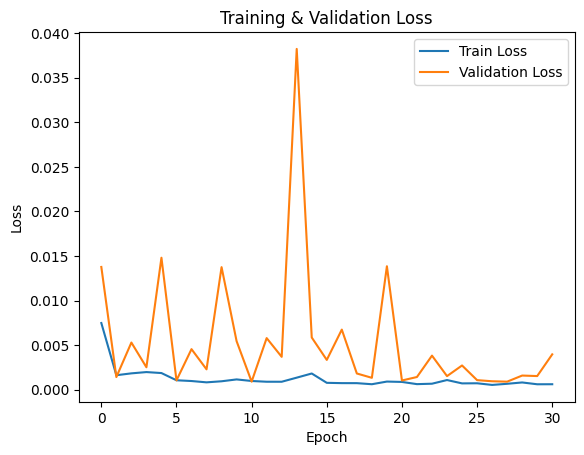

In [68]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training & Validation Loss')
plt.show()


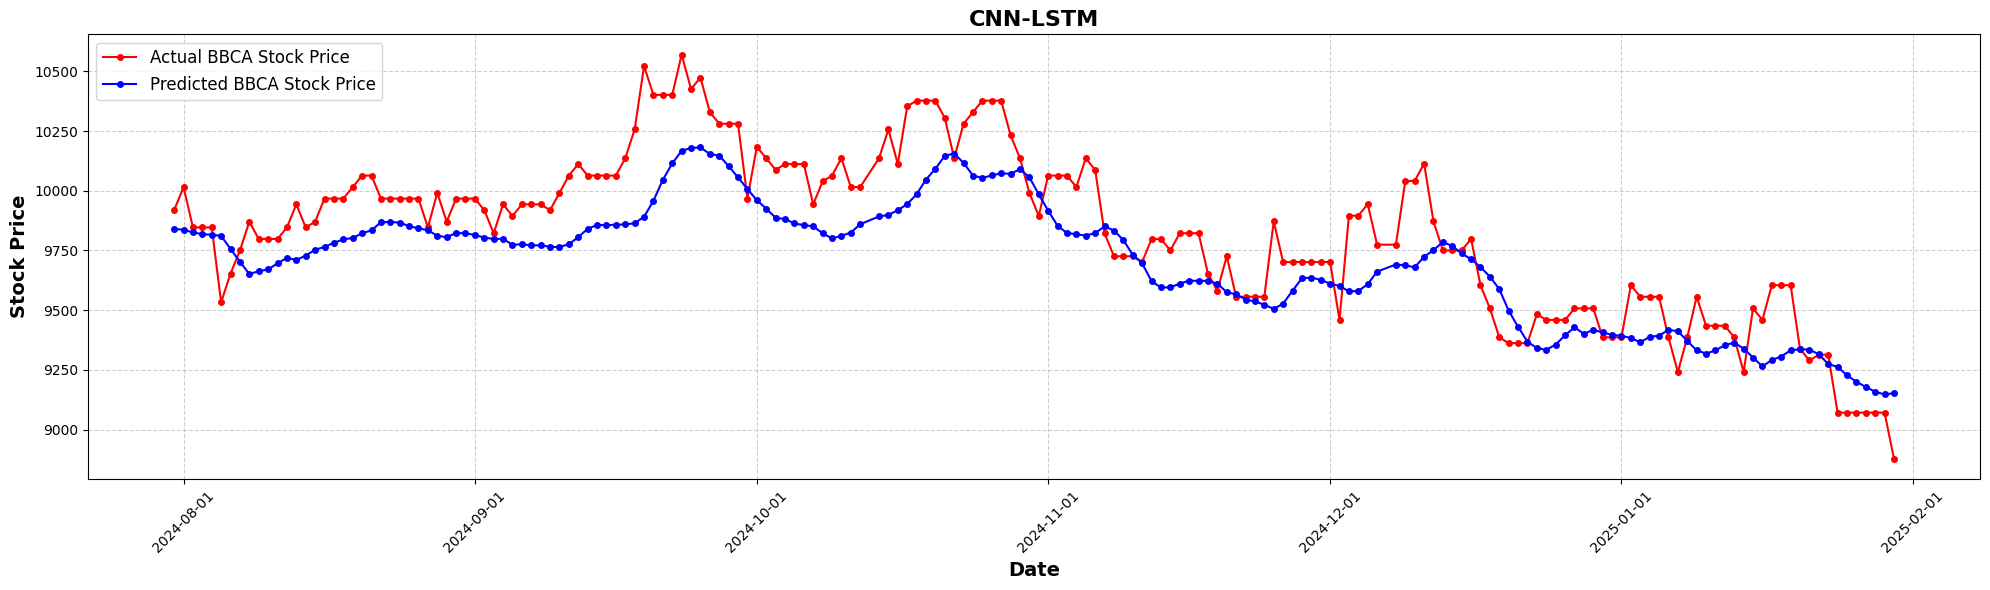

In [69]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# Konversi kolom 'Date' ke format datetime jika belum
test_data['Date'] = pd.to_datetime(test_data['Date'])

offset = look_back  # Biasanya 20

# Prediksi hasil model sudah di-inverse transform
y_pred = scaler_y.inverse_transform(pred_scaled)
y_true = scaler_y.inverse_transform(test_y[offset:])

plot_dates = test_data['Date'][offset:].reset_index(drop=True)

# Buat plot
plt.figure(figsize=(20, 6))

# Real values (y_true sudah di-inverse transform)
plt.plot(plot_dates, y_true, 'o-', color='red',
         linewidth=1.5, markersize=4, label="Actual BBCA Stock Price")

# Predicted values
plt.plot(plot_dates, y_pred, 'o-', color='blue',
         linewidth=1.5, markersize=4, label="Predicted BBCA Stock Price")

# Format sumbu dan tampilan
plt.xlabel("Date", fontsize=14, fontweight='bold')
plt.ylabel("Stock Price", fontsize=14, fontweight='bold')
plt.title("CNN-LSTM", fontsize=16, fontweight='bold')

plt.xticks(rotation=45)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())

plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
plt.show()
